# Notebook 06: Visualization Hub

This notebook centralizes all visualization for the hybrid bias correction
project. It generates diagnostic plots from three domains:

1. **QA Framework** (Steps 1--11e): Eight gridded plot types + four
   station-level breakdowns (region, component×region, province, station)
2. **Taylor Diagrams** (Steps 12--19): Product comparison against BMKG stations
3. **Station Validation** (Steps 20--23): Spatial maps, multi-threshold curves,
   and regional box plots from notebook 05 output

A unified batch cell (Step 24) generates all figures across all 36 dekadal
periods in a single run.

All plot functions are imported from `src/visualisation.py` and
`src/taylor_diagram.py`. Each plot type saves into its own sub-folder
under `figures/`.

::: {.callout-note title="What you'll do in this notebook"}
This is the **figure factory**. It reads the outputs of nb04 (QA) and nb05 (station validation) and renders every diagnostic figure the framework reports, in three families:

1. **QA maps** (Steps 4-11e) - spatial CQI, components, improvement, confidence, regional summaries.
2. **Taylor diagrams** (Steps 12-19) - correlation / variance / RMSE in one polar view, by domain, island, province, and station.
3. **Station validation** (Steps 20-23) - metric scatter maps, multi-threshold curves, regional box plots.

No new science here - just visualisation. If a figure looks wrong, the usual cause is a missing upstream file (re-run nb04 / nb05 for this period first).

**Runtime**: about **5 to 10 minutes** for one dekad; the unified batch at the bottom runs all 36 dekads and is the heaviest cell in the project (**30 to 45 minutes** on a Colab CPU).

**Concept reference**: [QA Framework](https://bennyistanto.github.io/hybrid-bias-correction/tutorials/qa-framework.html) and [Station Validation](https://bennyistanto.github.io/hybrid-bias-correction/tutorials/station-validation.html).
:::


## 1 Connect Google Drive (Colab only)

This section is only required when running in **Google Colab** and your project/data are stored in Google Drive.

- Mounting Drive makes your repository and datasets accessible under `/content/drive`.
- If you run this notebook locally (Jupyter / VS Code), **skip this section**.

**Expected structure (Drive)**
After mounting, your project root should contain:
- `notebooks/`
- `src/`
- `config.yml` (or `config.yaml`)

Proceed to the code cell below to mount Drive.


In [1]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists("/content/drive"):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount("/content/drive")

Successfully unmounted
Mounted at /content/drive


**Troubleshooting:**  
- If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under "/content/drive" from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.


## 2 Install packages (only if needed)

In most cases, **Google Colab already includes the packages required** for this workflow. The most common missing dependency is **`netCDF4`** (NetCDF I/O support).

### Check what is already installed (Colab)
Before installing anything, you can inspect the current environment by running `!pip list`.

- If all required packages are present and only `netCDF4` is missing, install **only `netCDF4`**.
- If other required packages are missing from `!pip list`, install them **together with** `netCDF4` in the code cell below.

### Local Jupyter note
If you are running in a **local environment** (Jupyter / VS Code), assume all dependencies were installed when preparing the environment following the **main repository README**. In that case, you can skip this section.

Proceed to the code cell below only when installation is necessary.


In [2]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4


## 3 Quality Assessment Visualization

This section generates spatial maps, distribution plots, and summary charts from
the composite quality indices computed by notebook 04. Eight complementary plot
types are produced, each highlighting a different aspect of correction quality:

1. **CQI spatial maps** -- continuous quality index for each correction method
2. **Categorical quality maps** -- Poor/Fair/Good/Excellent classification
3. **Method improvement map** -- CQI difference (LSEQM+DL minus LS)
4. **Component quality maps** -- basic, distribution, temporal sub-scores
5. **Confidence map** -- assessment reliability
6. **CQI distribution** -- empirical CDF and histogram
7. **Quality category summary** -- grouped bar chart of category percentages
8. **Component box plots** -- score distribution across methods

All plot functions are imported from `src/visualisation.py` and each type
saves into its own sub-folder under `figures/qa/`.

---


### Step 1: Environment Setup

Load the project paths and run config. Same setup pattern as nb02-nb05; no figures produced yet.

In [3]:
"""Step 1: Environment setup and configuration."""
import os
import sys
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# Resolve project root
if os.path.exists("/content/drive/MyDrive/hybrid-bias-correction"):
    project_root = "/content/drive/MyDrive/hybrid-bias-correction"
else:
    project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ===========================================================================
# AOI config selector
#   'config.yml'      -> full Indonesia (Zenodo input/output bundle)
#   'config_bali.yml' -> Bali example (ships with the repo, ~11 MB)
# Edit this single line to switch the entire pipeline between the two.
# ===========================================================================
CONFIG_FILE = 'config_bali.yml'

from src.config import initialize_config
initialize_config(os.path.join(project_root, CONFIG_FILE))
from src import config

# Output directories for all figure types
figures_dir = os.path.join(config.output_dir, "figures", "qa")
taylor_output_dir = os.path.join(config.output_dir, "figures", "taylor")
station_viz_dir = os.path.join(config.output_dir, "figures", "station_validation")

for d in [figures_dir, taylor_output_dir, station_viz_dir]:
    os.makedirs(d, exist_ok=True)

print(f"Project root:     {project_root}")
print(f"QA figures dir:   {figures_dir}")
print(f"Taylor dir:       {taylor_output_dir}")
print(f"Station viz dir:  {station_viz_dir}")

2026-05-22 04:37:29,235 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config_bali.yml
2026-05-22 04:37:29,239 - INFO - Configured main_dir '/content/hybrid-bias-correction' does not exist on this system. Using auto-detected project root: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 04:37:29,245 - INFO - Configuration initialized successfully.
2026-05-22 04:37:29,245 - INFO -   Main directory: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 04:37:29,247 - INFO -   Input directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali
2026-05-22 04:37:29,248 - INFO -   Output directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output
2026-05-22 04:37:29,250 - INFO -   Interactive mode: False
Project root:     /content/drive/MyDrive/hybrid-bias-correction
QA figures dir:   /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa
Taylor dir:       /content/drive/MyDrive/hybrid-

### Step 2: Select Period and Quality Mode

Choose the month and dekad to visualise, and the quality mode to plot. The default matches the Bali figures shown on the docs site, so your output should look like the [QA Framework tutorial](https://bennyistanto.github.io/hybrid-bias-correction/tutorials/qa-framework.html) figures.

In [4]:
"""Step 2: User inputs for interactive exploration."""

# Select month (1-12) and dekad (1, 2, or 3)
month = 1
dekad = 1

# Quality mode: "qualitysd" (single-dekad aggregated) or "qualityts" (per-year)
quality_prefix = "qualitysd"

print(f"Period: month {month}, dekad {dekad}")
print(f"Quality mode: {quality_prefix}")


Period: month 1, dekad 1
Quality mode: qualitysd


### Step 3: Load Quality Data


In [5]:
"""Step 3: Load QA NetCDF files for all correction methods."""
from src.visualisation import load_quality_data

quality_data = load_quality_data(
    month, dekad,
    quality_prefix=quality_prefix,
    config=config,
)

print(f"Loaded {len(quality_data)} method(s): {list(quality_data.keys())}")


Loaded 3 method(s): ['LS', 'LSEQM', 'LSEQMDL']


### Step 4: CQI Spatial Maps

::: {.callout-tip title="What you should see"}
Three side-by-side maps (LS / LSEQM / LSEQM+DL) of the Continuous Quality Index. For Bali they should be mostly green-to-yellow (CQI 0.4 to 0.6) and spatially smooth. The three panels will look **very similar** to each other - the methods differ more in the distribution they produce than in this composite score, which is the expected, documented pattern.
:::


2026-05-22 04:12:40,216 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_cqi_spatial/bali_cli_qa_viz_qualitysd_cqi_spatial_month01_dekad01.png


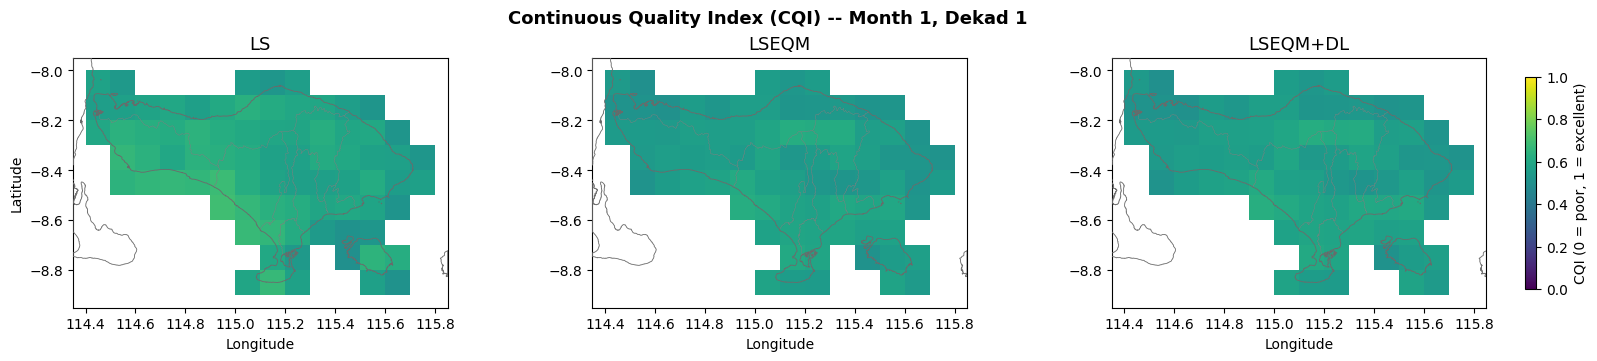

In [ ]:
"""Step 4: Continuous Quality Index spatial maps."""
from src.visualisation import plot_cqi_spatial

fig = plot_cqi_spatial(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 5: Categorical Quality Maps


2026-05-22 04:12:42,770 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_categorical_spatial/bali_cli_qa_viz_qualitysd_categorical_spatial_month01_dekad01.png


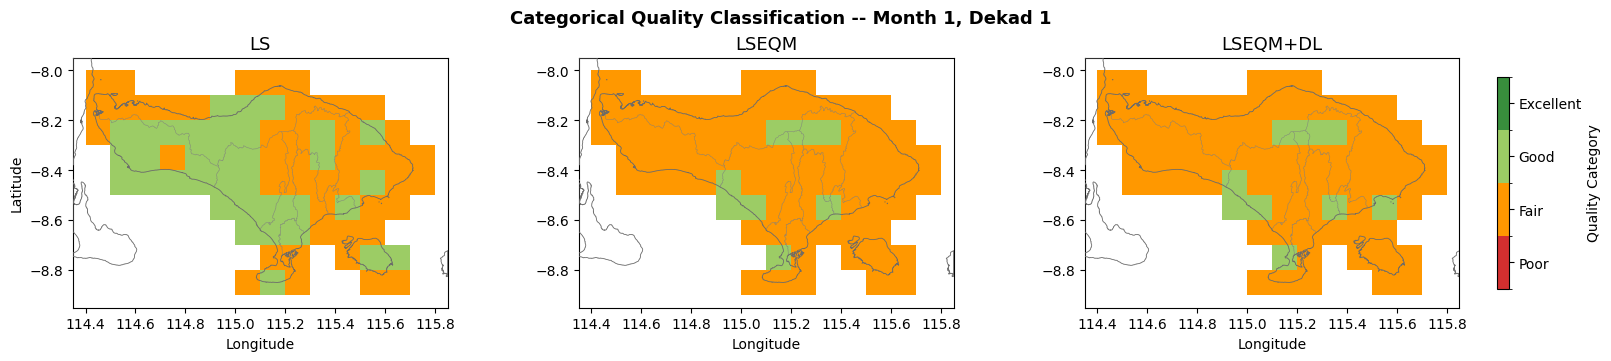

In [ ]:
"""Step 5: Categorical quality classification maps."""
from src.visualisation import plot_categorical_spatial

fig = plot_categorical_spatial(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 6: Method Improvement Map


Mean improvement:  -0.0369
Median improvement: -0.0374
Pixels improved:   15 (18.8%)
Pixels degraded:   64 (80.0%)
Pixels unchanged:  1 (1.2%)
2026-05-22 04:12:44,800 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_improvement/bali_cli_qa_viz_qualitysd_improvement_month01_dekad01.png


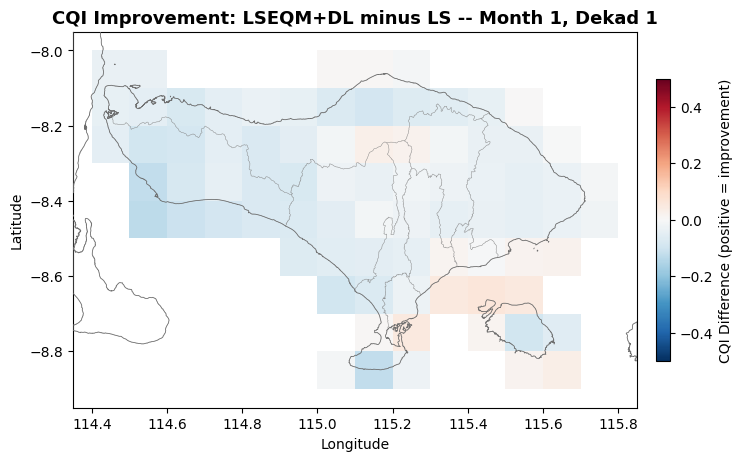

In [ ]:
"""Step 6: CQI improvement map (LSEQM+DL minus LS)."""
from src.visualisation import plot_improvement

fig, imp_stats = plot_improvement(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 7: Component Quality Maps


2026-05-22 04:12:47,372 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_components/bali_cli_qa_viz_qualitysd_components_month01_dekad01.png


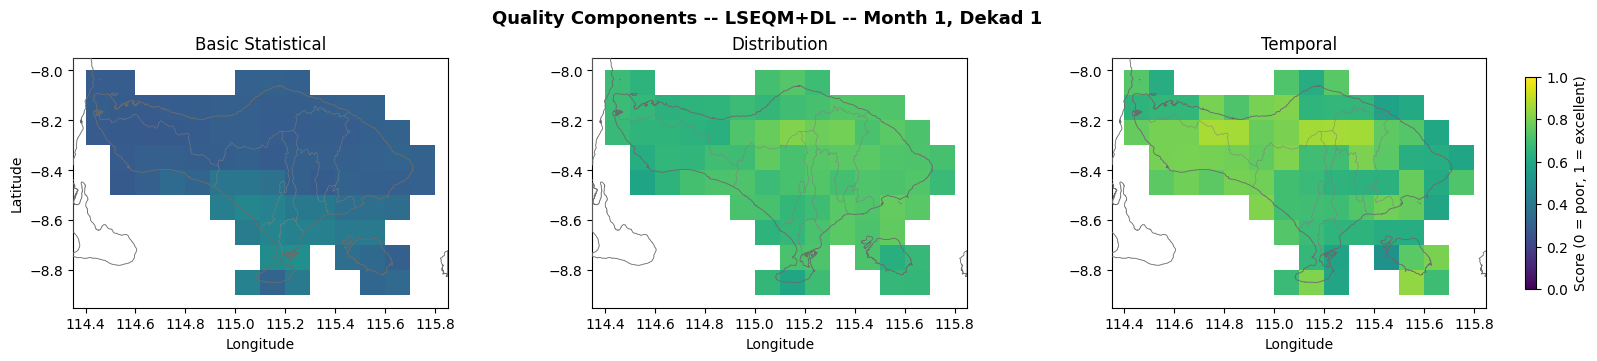

In [ ]:
"""Step 7: Component quality maps (basic, distribution, temporal)."""
from src.visualisation import plot_components

fig = plot_components(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 8: Confidence Map


Mean confidence:  0.3915
Min confidence:   0.3659
Max confidence:   0.4781
2026-05-22 04:12:49,302 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_confidence/bali_cli_qa_viz_qualitysd_confidence_month01_dekad01.png


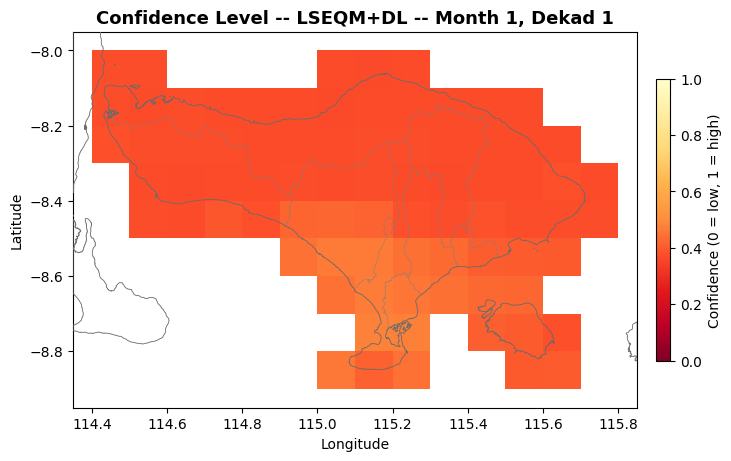

In [ ]:
"""Step 8: Confidence level spatial map."""
from src.visualisation import plot_confidence

fig = plot_confidence(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 9: CQI Distribution Analysis


Median CQI (LS): 0.5947
Median CQI (LSEQM): 0.5531
Median CQI (LSEQM+DL): 0.5536
2026-05-22 04:12:50,815 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_cqi_distribution/bali_cli_qa_viz_qualitysd_cqi_distribution_month01_dekad01.png


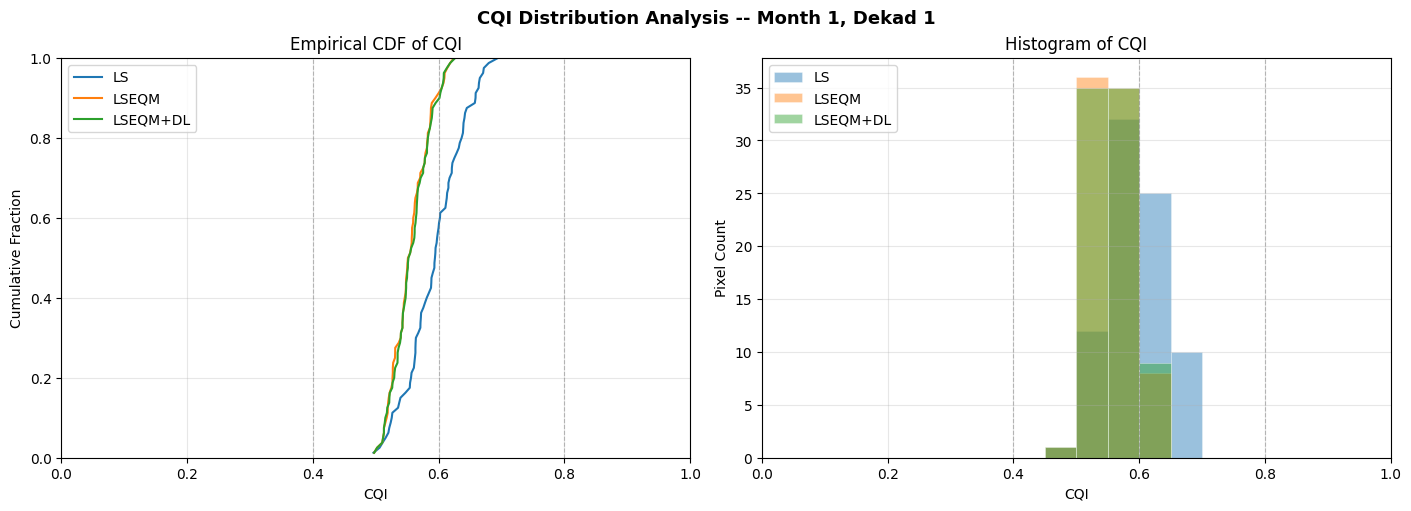

In [ ]:
"""Step 9: Empirical CDF and histogram of CQI."""
from src.visualisation import plot_cqi_distribution

fig = plot_cqi_distribution(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 10: Quality Category Summary



Method            Poor      Fair      Good   Excellent       Total
------------------------------------------------------------------
LS                0.0%     56.2%     43.8%        0.0%          80
LSEQM             0.0%     90.0%     10.0%        0.0%          80
LSEQM+DL          0.0%     88.8%     11.2%        0.0%          80
2026-05-22 04:12:51,984 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_category_summary/bali_cli_qa_viz_qualitysd_category_summary_month01_dekad01.png


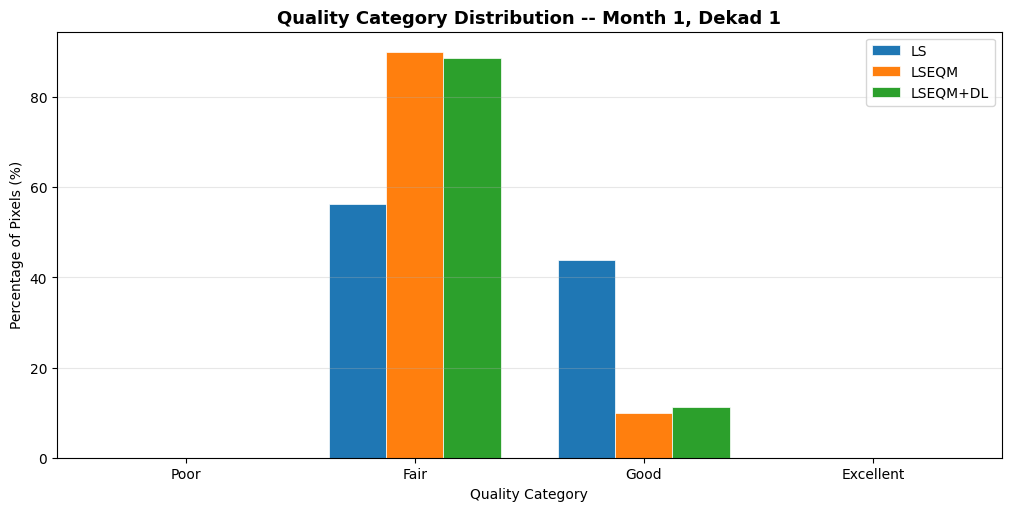

In [ ]:
"""Step 10: Grouped bar chart of quality category percentages."""
from src.visualisation import plot_category_summary

fig, cat_summary = plot_category_summary(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 11: Component Box Plots


2026-05-22 04:12:53,598 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_component_boxplots/bali_cli_qa_viz_qualitysd_component_boxplots_month01_dekad01.png


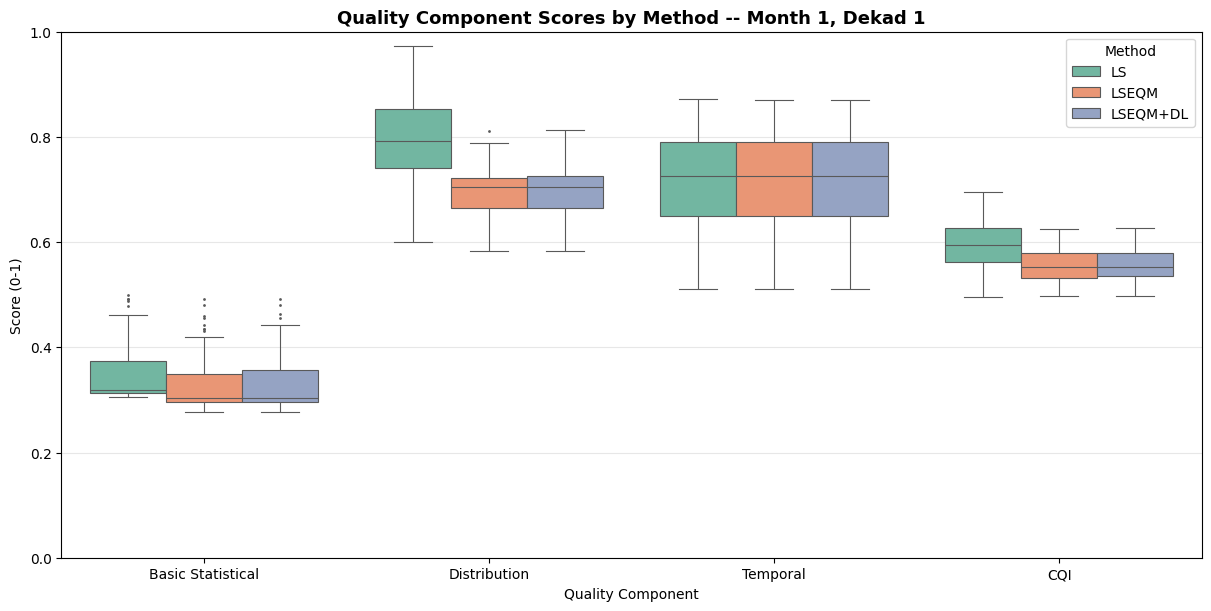

In [ ]:
"""Step 11: Component score box plots across methods."""
from src.visualisation import plot_component_boxplots

fig = plot_component_boxplots(
    quality_data, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)


### Step 11b: QA at Station Locations — Regional Summary

Extract gridded QA values at BMKG station locations, then visualize
median CQI grouped by the 7 island regions (one bar per method).

2026-05-22 04:12:54,291 - INFO - Loaded 4 station locations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_stations_location.csv
2026-05-22 04:12:55,053 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_qa_regional/bali_cli_qa_viz_qualitysd_qa_regional_month01_dekad01.png


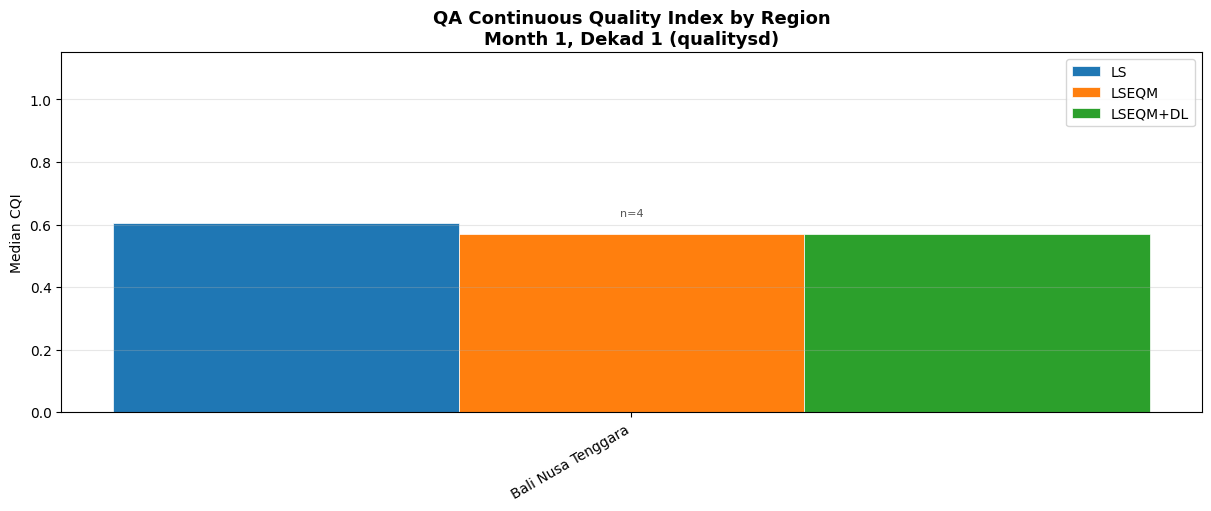

In [ ]:
"""Step 11b: QA CQI by region — grouped bar chart."""
from src.station_density import load_station_locations
from src.visualisation import plot_qa_regional_bars

station_df = load_station_locations(config.STATION_FILE)

fig = plot_qa_regional_bars(
    quality_data, station_df, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)

### Step 11c: QA Components by Region

Box plots of the four QA component scores (CQI, basic statistical,
distribution, temporal) at station locations, grouped by island region.
Uses the best method (LSEQM+DL) only.

2026-05-22 04:12:56,764 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_qa_component_region/bali_cli_qa_viz_qualitysd_qa_component_region_lseqmdl_month01_dekad01.png


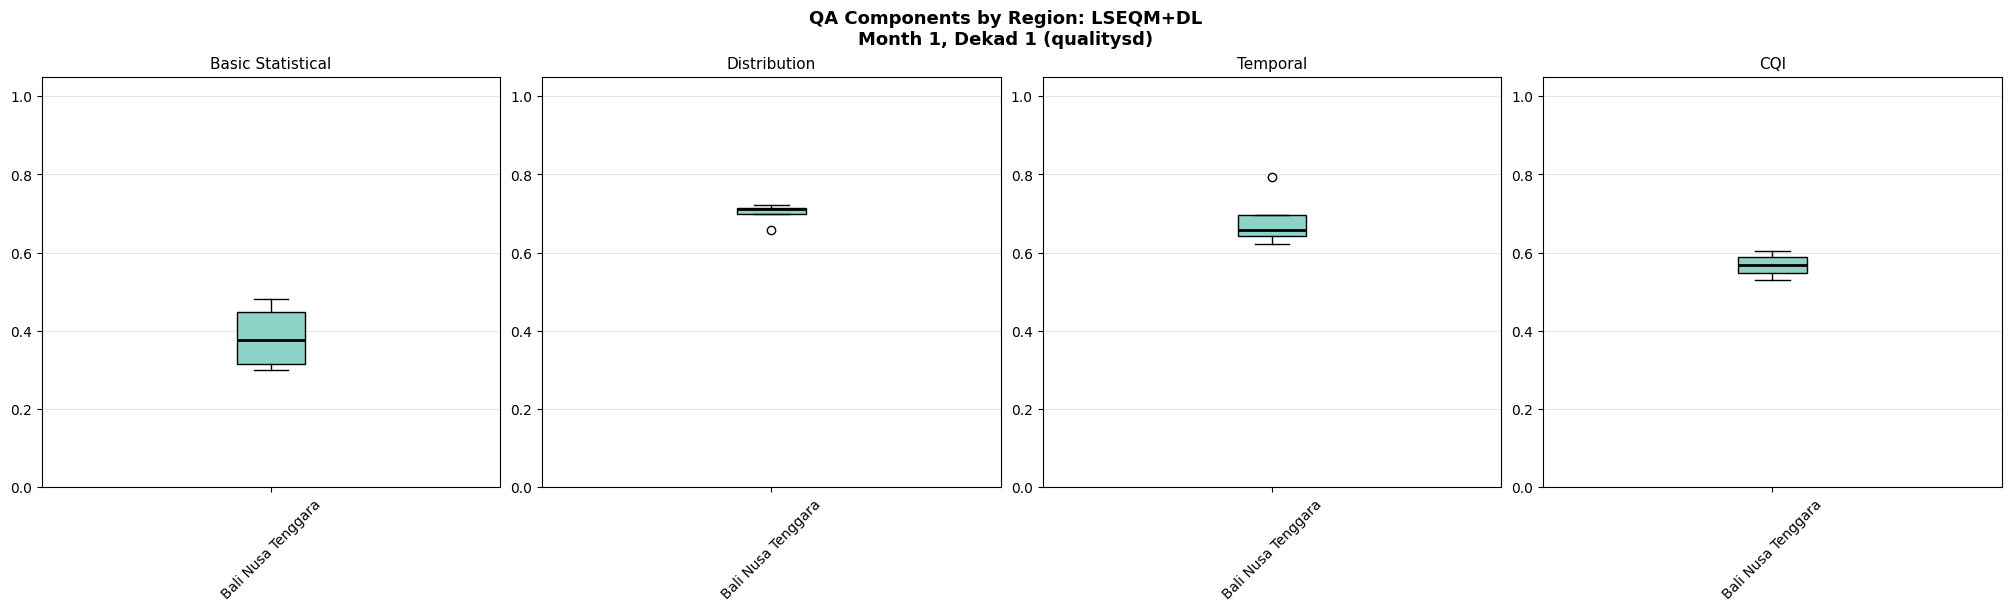

In [ ]:
"""Step 11c: QA component box plots by region."""
from src.visualisation import plot_qa_component_by_region

fig = plot_qa_component_by_region(
    quality_data, station_df, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)

### Step 11d: QA CQI by Province

Horizontal bar chart of median CQI per province (best method),
colour-coded by parent island region.

2026-05-22 04:12:58,192 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/qa/qualitysd_qa_province/bali_cli_qa_viz_qualitysd_qa_province_lseqmdl_month01_dekad01.png


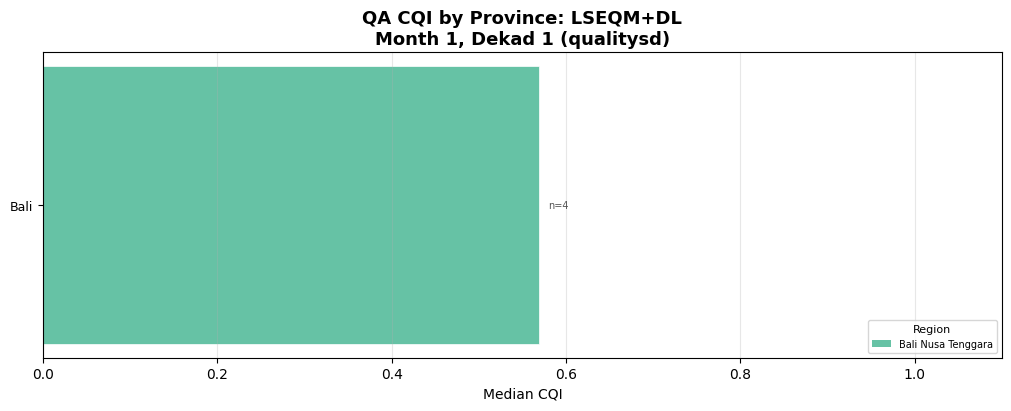

In [ ]:
"""Step 11d: QA CQI by province."""
from src.visualisation import plot_qa_province_bars

fig = plot_qa_province_bars(
    quality_data, station_df, month, dekad,
    quality_prefix=quality_prefix,
    output_dir=figures_dir,
)

### Step 11e: QA CQI per Station

Per-station CQI bar chart (best method), filtered by region.
Change `region_filter` to view a different island group, or set to
`None` to show all stations.

In [ ]:
"""Step 11e: QA CQI per station (single region)."""
from src.visualisation import plot_qa_station_bars

fig = plot_qa_station_bars(
    quality_data, station_df, month, dekad,
    quality_prefix=quality_prefix,
    region_filter="Jawa",  # Change to view other regions, or None for all
    output_dir=figures_dir,
)

## 4 Taylor Diagram Analysis

This notebook generates Taylor diagrams that visually summarize the performance
of bias-corrected precipitation products against independent BMKG station
observations.

### What is a Taylor Diagram?

A Taylor diagram (Taylor, 2001) simultaneously displays three statistics in a
single polar plot:

- **Pearson correlation** (angular axis) -- linear agreement with reference
- **Standard deviation ratio** (radial axis) -- variability match
- **Centered RMSE** (distance from reference point) -- overall error

Each product appears as a marker; perfect agreement places the marker on the
reference point (correlation = 1, normalized std = 1). Progressive improvement
from raw satellite to fully corrected product is immediately visible as markers
move toward the reference.

### Products Compared

| Product | Description |
|---------|-------------|
| CPC-UNI | Gauge-based reference (0.5\u00b0, used as correction target) |
| IMERG-L | Raw satellite precipitation (uncorrected) |
| IMERG-F | Gauge-adjusted satellite precipitation (uncorrected) |
| LS | Linear Scaling corrected |
| LSEQM | LS + EQM with GPD tail adjustment |
| LSEQM+DL | Full hybrid framework (LS + EQM + GPD + CNN) |

### Spatial Aggregation Levels

1. **Domain-wide** -- all 171+ BMKG stations pooled (for the paper)
2. **By island group** -- 7 regions (Sumatra, Jawa, Kalimantan, etc.)
3. **By province** -- individual provinces (min 3 stations)
4. **By station** -- individual station markers with domain aggregate overlay

### Prerequisites

- Notebook 02 must have completed (corrected files for LS, LSEQM, LSEQMDL)
- BMKG station data CSV must be available (location + observations)
- CPC-UNI and IMERG-L files must be available

### Reference

Taylor, K. E. (2001). Summarizing multiple aspects of model performance in a
single diagram. *Journal of Geophysical Research*, 106(D7), 7183--7192.

### Step 12: Compute Taylor Diagram Statistics

This step pairs each product against each BMKG station's full daily record and accumulates the statistics that the Taylor diagrams need. It is the most time-consuming cell in this section.

::: {.callout-tip title="What you should see"}
The cell returns three values (`acc`, `station_locs`, `acc_by_dekad`) and prints the per-product pair counts. For the 4-station Bali bundle the totals are small; on the full Indonesia run this is where most of the figure-generation time goes. A `0 pairs` line for a product means its file is missing for that dekad - re-run nb05 first.
:::


In [6]:
"""
Step 12: Compute Taylor statistics across all 36 dekads.

This is the most time-consuming step. The resulting accumulator object
is reused by all subsequent plotting steps.
"""
from src.taylor_diagram import compute_all_taylor_stats

# acc          : pooled per-station accumulator across all 36 dekads
# station_locs : station metadata DataFrame
# acc_by_dekad : {(month, dekad_start): _Accumulator} for per-dekad views
acc, station_locs, acc_by_dekad = compute_all_taylor_stats(config, progress=True)

print(f"\nAccumulator products: {acc.product_keys}")
print(f"Stations: {acc.n_stations}")
print(f"Per-dekad accumulators: {len(acc_by_dekad)}")
print("Total paired observations per product:")
for i, key in enumerate(acc.product_keys):
    total_n = acc.n[i].sum()
    active_stations = (acc.n[i] > 0).sum()
    print(f"  {key:>10s}: {total_n:>12,d} pairs across {active_stations} stations")


  Loaded 4 station locations
  Matched 4/4 stations to obs data
  Station obs: 7670 rows, 2001-01-01 00:00:00 to 2021-12-31 00:00:00, dtype=datetime64[ns]
  Processing dekad  1/36 (month 01, days  1-10) ...    cpc: 250 dates, type=datetime64
    imergl: 250 dates, type=datetime64
    imergf: 250 dates, type=datetime64
    ls: 250 dates, type=datetime64
    lseqm: 250 dates, type=datetime64
    lseqmdl: 250 dates, type=datetime64
  Processing dekad 36/36 (month 12, days 21-31) ...
  Done computing Taylor statistics (184,080 total paired observations).

Accumulator products: ['cpc', 'imergl', 'imergf', 'ls', 'lseqm', 'lseqmdl']
Stations: 4
Per-dekad accumulators: 36
Total paired observations per product:
         cpc:       19,868 pairs across 4 stations
      imergl:       19,871 pairs across 4 stations
      imergf:       19,871 pairs across 4 stations
          ls:       19,871 pairs across 4 stations
       lseqm:       19,871 pairs across 4 stations
     lseqmdl:       19,871 pairs 

### Step 13: Domain-Wide Taylor Diagram

Pool all station data across the full Indonesian domain. This produces one
marker per product, showing the overall performance comparison.

**This is the figure intended for the paper** (Figure 4 in revision notes).


Domain-wide Taylor Statistics (median of per-station)
Product      |   Corr |    σ_obs |    σ_prd | σ ratio |     RMSE |    CRMSE |     Bias |         N
--------------------------------------------------------------------------------------------------
CPC-UNI      |  0.283 |   15.797 |   11.378 |   0.720 |   16.704 |   16.656 |   -1.270 |     19868
IMERG-L      |  0.336 |   15.796 |   11.801 |   0.747 |   16.275 |   16.231 |   -1.208 |     19871
IMERG-F      |  0.332 |   15.796 |   10.713 |   0.678 |   15.953 |   15.875 |   -1.576 |     19871
LS           |  0.326 |   15.796 |   11.922 |   0.755 |   16.429 |   16.398 |   -1.007 |     19871
LSEQM        |  0.326 |   15.796 |   13.555 |   0.858 |   17.148 |   17.137 |   -0.618 |     19871
LSEQM+DL     |  0.328 |   15.796 |   13.450 |   0.852 |   17.068 |   17.058 |   -0.599 |     19871
  Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/taylor/taylor_domain_wide.png


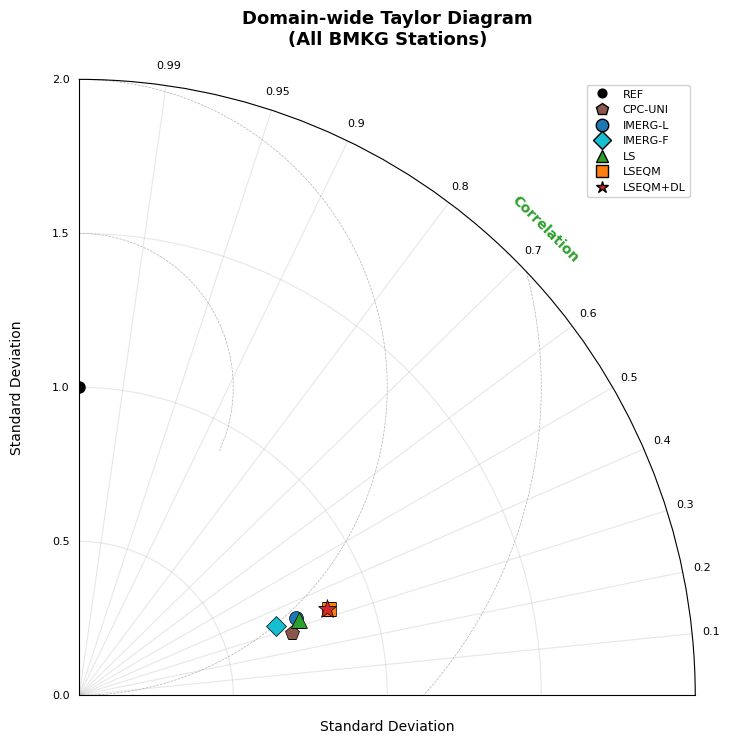

In [7]:
"""
Step 13: Generate domain-wide Taylor diagram.
"""
from src.taylor_diagram import generate_domain_taylor, print_taylor_stats

fig_domain = generate_domain_taylor(
    acc, station_locs,
    output_dir=taylor_output_dir,
    normalize=True,
    max_std_ratio=2.0,
)
plt.show()

### Step 14: Taylor Diagrams by Island Group

Generate a multi-panel figure with one Taylor diagram per major island
group: Sumatra, Jawa, Kalimantan, Sulawesi, Bali Nusa Tenggara, Maluku,
and Papua. Stations are pooled within each region.

This reveals regional differences in correction performance (e.g., Java
with dense gauge coverage vs. Papua with sparse coverage).

  Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/taylor/taylor_by_island.png


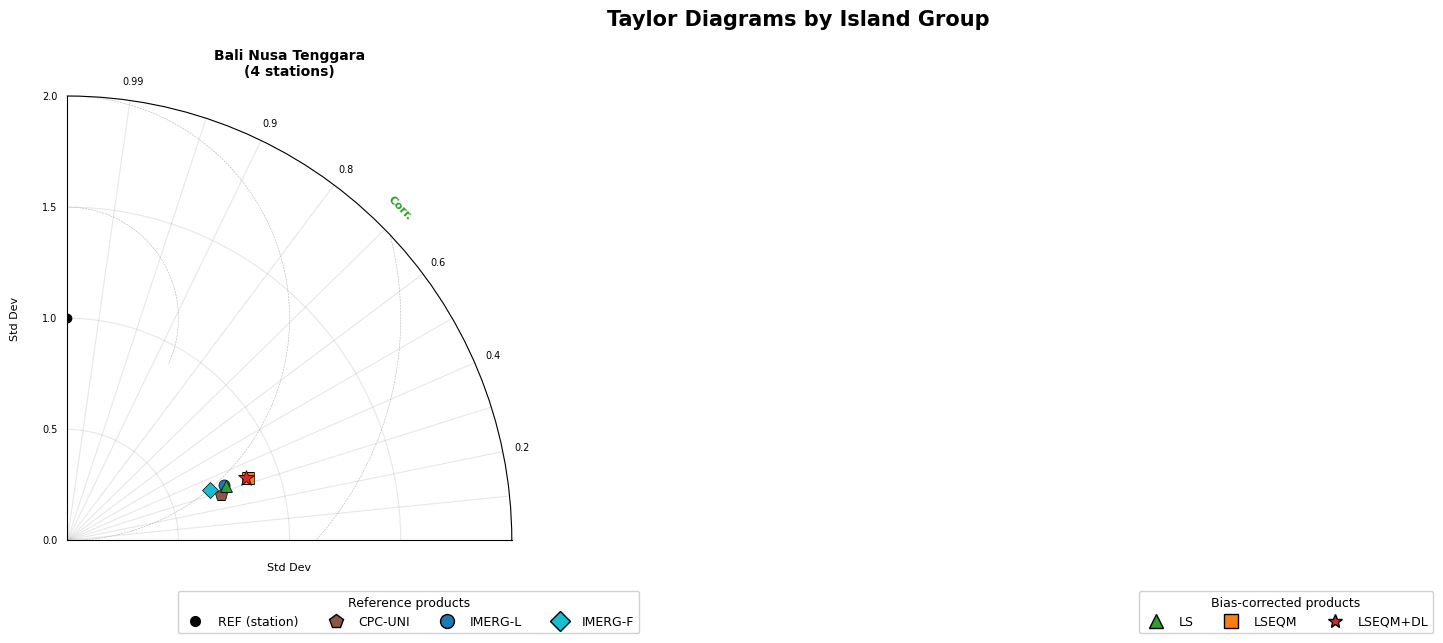

In [8]:
"""
Step 14: Generate per-island Taylor diagrams.
"""
from src.taylor_diagram import generate_island_taylor

fig_island = generate_island_taylor(
    acc, station_locs,
    output_dir=taylor_output_dir,
    normalize=True,
)
plt.show()

### Step 15: Taylor Diagrams by Province

Generate per-province Taylor diagrams for provinces with at least 3
stations. Provinces with fewer stations are skipped as the pooled
statistics would be unreliable.

This provides the finest administrative-level breakdown of correction
performance.

  Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/taylor/taylor_by_province.png


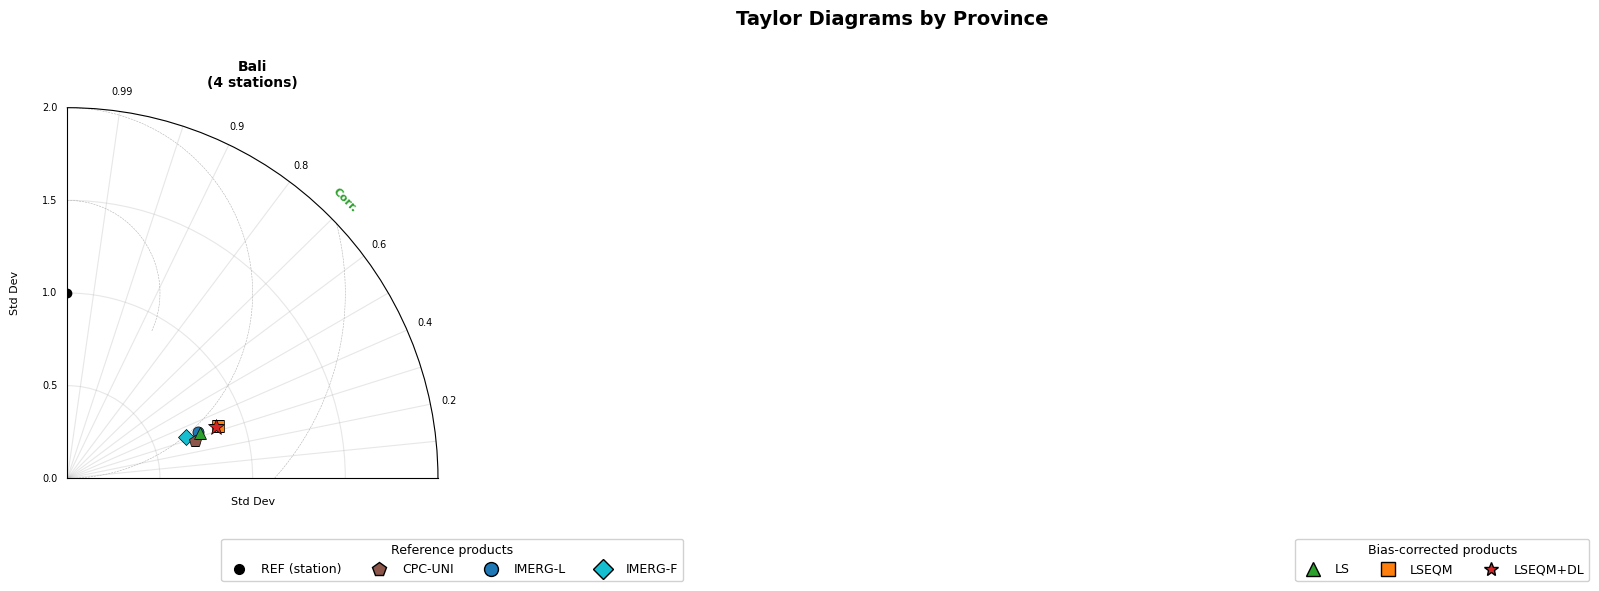

In [9]:
"""
Step 15: Generate per-province Taylor diagrams.
"""
from src.taylor_diagram import generate_province_taylor

fig_province = generate_province_taylor(
    acc, station_locs,
    output_dir=taylor_output_dir,
    min_stations=3,
    normalize=True,
)
plt.show()

### Step 16: Station-Level Taylor Diagram

Shows individual station markers (small, semi-transparent) for each
product, overlaid with larger opaque markers representing the domain-wide
aggregate. This reveals the spread of per-station performance within each
product category.

Stations that cluster tightly around the aggregate marker indicate
consistent correction quality across the network. Wide scatter indicates
spatially variable performance.

  Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/taylor/taylor_by_station.png


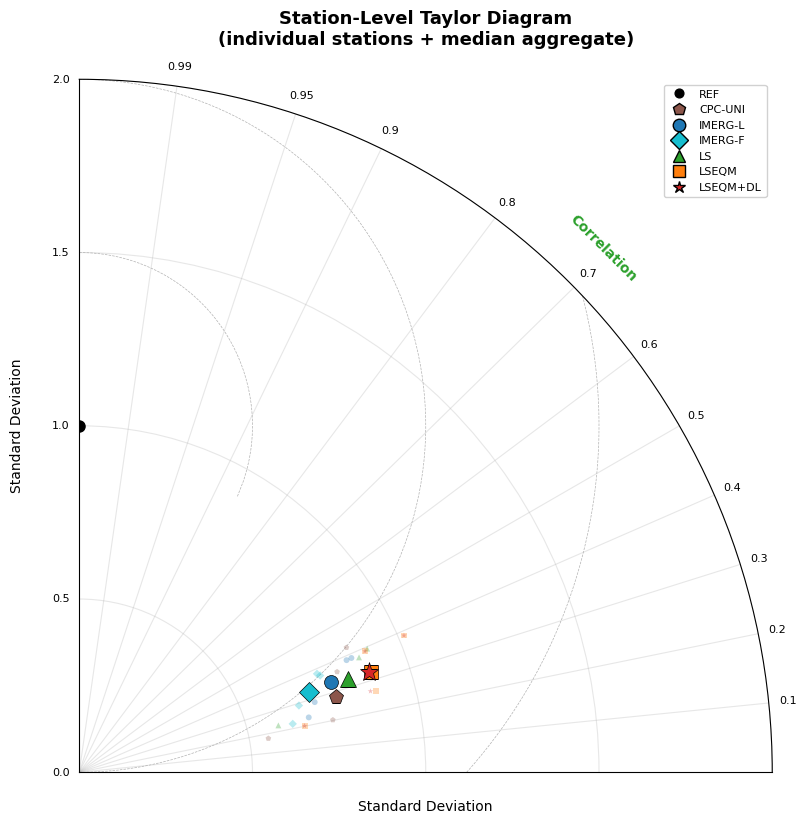

In [10]:
"""
Step 16: Generate station-level Taylor diagram.
"""
from src.taylor_diagram import generate_station_taylor

fig_station = generate_station_taylor(
    acc, station_locs,
    output_dir=taylor_output_dir,
    normalize=True,
    max_std_ratio=2.0,
)
plt.show()

### Step 17: Save Statistics to CSV

Export per-station Taylor statistics for all products to a CSV file.
This enables further analysis (e.g., in R, Excel) without re-running
the computation.

In [11]:
"""
Step 17: Save per-station Taylor statistics to CSV.
"""
from src.taylor_diagram import save_taylor_stats_csv

csv_path = os.path.join(taylor_output_dir, 'taylor_statistics_per_station.csv')
stats_df = save_taylor_stats_csv(acc, station_locs, csv_path)

print(f"\nCSV shape: {stats_df.shape}")
print(f"Columns: {list(stats_df.columns)}")
stats_df.head(10)

  Saved Taylor statistics CSV: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/taylor/taylor_statistics_per_station.csv

CSV shape: (4, 48)
Columns: ['station_id', 'station_name', 'lon', 'lat', 'province', 'region', 'cpc_correlation', 'cpc_std_obs', 'cpc_std_prd', 'cpc_rmse', 'cpc_crmse', 'cpc_bias', 'cpc_n', 'imergl_correlation', 'imergl_std_obs', 'imergl_std_prd', 'imergl_rmse', 'imergl_crmse', 'imergl_bias', 'imergl_n', 'imergf_correlation', 'imergf_std_obs', 'imergf_std_prd', 'imergf_rmse', 'imergf_crmse', 'imergf_bias', 'imergf_n', 'ls_correlation', 'ls_std_obs', 'ls_std_prd', 'ls_rmse', 'ls_crmse', 'ls_bias', 'ls_n', 'lseqm_correlation', 'lseqm_std_obs', 'lseqm_std_prd', 'lseqm_rmse', 'lseqm_crmse', 'lseqm_bias', 'lseqm_n', 'lseqmdl_correlation', 'lseqmdl_std_obs', 'lseqmdl_std_prd', 'lseqmdl_rmse', 'lseqmdl_crmse', 'lseqmdl_bias', 'lseqmdl_n']


,station_id,station_name,lon,lat,province,region,cpc_correlation,cpc_std_obs,cpc_std_prd,cpc_rmse,...,lseqm_crmse,lseqm_bias,lseqm_n,lseqmdl_correlation,lseqmdl_std_obs,lseqmdl_std_prd,lseqmdl_rmse,lseqmdl_crmse,lseqmdl_bias,lseqmdl_n
0,97230,Stasiun Meteorologi I Gusti Ngurah Rai,115.17000,-8.75000,Bali,Bali Nusa Tenggara,0.422967,14.076497,11.978168,14.113797,...,15.711541,0.129558,7066,0.388224,14.084034,14.321515,15.712075,15.711541,0.129558,7066
1,97232,Stasiun Geofisika Denpasar,115.21000,-8.67689,Bali,Bali Nusa Tenggara,0.363039,17.173476,13.714254,17.725246,...,18.037177,-0.733262,2839,0.390044,17.173476,15.374826,18.052076,18.037177,-0.733262,2839
2,97234,Pos Pengamatan Kahang-Kahang,115.61083,-8.36500,Bali,Bali Nusa Tenggara,0.202155,14.420211,10.777178,16.198327,...,16.559040,-0.503573,4528,0.268154,14.418665,12.579447,16.403721,16.397118,-0.465405,4528
3,97236,Stasiun Klimatologi Jembrana,114.61760,-8.34100,Bali,Bali Nusa Tenggara,0.176104,17.358224,9.624979,18.551897,...,18.796229,-2.543381,5438,0.202014,17.358199,11.524528,18.967525,18.796229,-2.543381,5438


### Step 18: One-Click Generation (Alternative)

If you want to generate everything in a single call instead of running
Steps 12--17 individually, use `generate_all_taylor_diagrams()`. This
computes statistics and produces all four diagram variants plus the CSV.

**Note**: Only run this if you have NOT already run Steps 12--17 above,
as it will repeat the computation.

In [ ]:
"""
Step 18 (Alternative): Generate all Taylor diagrams in one call.

Uncomment and run this cell INSTEAD of Steps 12-17 if preferred.
"""
# from src.taylor_diagram import generate_all_taylor_diagrams
#
# acc, station_locs, acc_by_dekad = generate_all_taylor_diagrams(
#     config,
#     output_dir=taylor_output_dir,
# )

### Step 19: Custom Taylor Diagram (On-Demand)

Generate a Taylor diagram for a specific subset of products or a specific
region. Modify the parameters below as needed.

**Examples:**
- Show only corrected products (exclude raw IMERG)
- Focus on a single island
- Compare only LSEQM vs LSEQM+DL

In [ ]:
"""
Step 19: Custom Taylor diagram for a specific region or product subset.

Modify TARGET_REGION and PRODUCTS_TO_SHOW as needed.
"""
from src.taylor_diagram import plot_taylor_diagram, print_taylor_stats

# --- User settings ---
TARGET_REGION = 'Jawa'  # One of: Sumatra, Jawa, Kalimantan, Sulawesi,
                        #         Bali Nusa Tenggara, Maluku, Papua
                        # Set to None for domain-wide

PRODUCTS_TO_SHOW = None  # None = all products, or e.g. ['ls', 'lseqm', 'lseqmdl']

# --- Compute stats ---
if TARGET_REGION is not None:
    mask = (station_locs['Region'] == TARGET_REGION).values
    n_st = mask.sum()
    stats = acc.compute_median(station_mask=mask)
    title = f'Taylor Diagram: {TARGET_REGION} ({n_st} stations)'
else:
    stats = acc.compute_median()
    title = 'Taylor Diagram: Domain-wide'

# --- Print table ---
print_taylor_stats(stats, title=title)

# --- Plot ---
fig, ax = plot_taylor_diagram(
    stats,
    title=title,
    normalize=True,
    products_to_show=PRODUCTS_TO_SHOW,
    max_std_ratio=2.0,
)
plt.show()

## 5 Station Validation Visualization

This section visualizes the independent station validation results from
notebook 05. Three plot types are generated from the CSV outputs:

1. **Station metric scatter maps** -- spatial distribution of 6 key metrics
2. **WMO multi-threshold curves** -- categorical skill across intensity thresholds
3. **Regional box plots** -- metric distributions by main island

All plot functions are imported from `src/visualisation.py` and save into
sub-folders under `figures/station_validation/`.

**Prerequisites**: Notebook 05 batch must have completed (CSV outputs in
`data/output/station_validation/`).

### Step 20: Load Station Validation CSV

Load per-station validation metrics and multi-threshold summaries from
the CSV files produced by notebook 05. Set `month` and `dekad` to match
the period selected in Step 2.

In [12]:
"""Step 20: Load station validation CSV data for a single period."""
from src.station_density import load_station_locations
from src.station_validation import merge_station_metadata

# Load station locations
station_df = load_station_locations(config.STATION_FILE)

# Build path to station validation CSV
sv_dir = getattr(config, "STATION_VALIDATION_OUTPUT_DIR", None)
if sv_dir is None:
    sv_dir = os.path.join(config.output_dir, "station_validation")

month_str = f"{month:02d}"
dekad_map = {1: "01", 2: "11", 3: "21"}
dekad_str = dekad_map[dekad]

# Load metrics for each method
sv_metrics = {}
for method_key, method_abbr in [("LS", "ls"), ("LSEQM", "lseqm"), ("LSEQMDL", "lseqmdl")]:
    csv_path = os.path.join(
        sv_dir,
        f"station_validation_{method_abbr}_month{month_str}_dekad{dekad_str}.csv",
    )
    if os.path.exists(csv_path):
        sv_metrics[method_key] = pd.read_csv(csv_path, index_col=0)
        print(f"  {method_key}: {len(sv_metrics[method_key])} stations from {csv_path}")
    else:
        print(f"  {method_key}: not found -- {csv_path}")

# Load multi-threshold summaries
sv_mt_summaries = {}
for method_key, method_abbr in [("LS", "ls"), ("LSEQM", "lseqm"), ("LSEQMDL", "lseqmdl")]:
    mt_csv = os.path.join(
        sv_dir,
        f"multi_threshold_summary_{method_abbr}_month{month_str}_dekad{dekad_str}.csv",
    )
    if os.path.exists(mt_csv):
        sv_mt_summaries[method_key] = pd.read_csv(mt_csv, index_col=0)

print(f"\nMetrics loaded: {list(sv_metrics.keys())}")
print(f"Multi-threshold summaries: {list(sv_mt_summaries.keys())}")

2026-05-22 04:39:33,654 - INFO - Loaded 4 station locations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_stations_location.csv
  LS: 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_validation_ls_month01_dekad01.csv
  LSEQM: 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_validation_lseqm_month01_dekad01.csv
  LSEQMDL: 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_validation_lseqmdl_month01_dekad01.csv

Metrics loaded: ['LS', 'LSEQM', 'LSEQMDL']
Multi-threshold summaries: ['LS', 'LSEQM', 'LSEQMDL']


### Step 21: Station Metric Scatter Maps

Spatial scatter plots showing the distribution of 6 key validation metrics
(correlation, NSE, relative bias, RMSE, CSI, POD) at each BMKG station
location for the best correction method.

2026-05-22 04:39:53,007 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/station_validation/station_validation_metric_maps/bali_cli_qa_viz_station_validation_metric_maps_lseqmdl_month01_dekad01.png


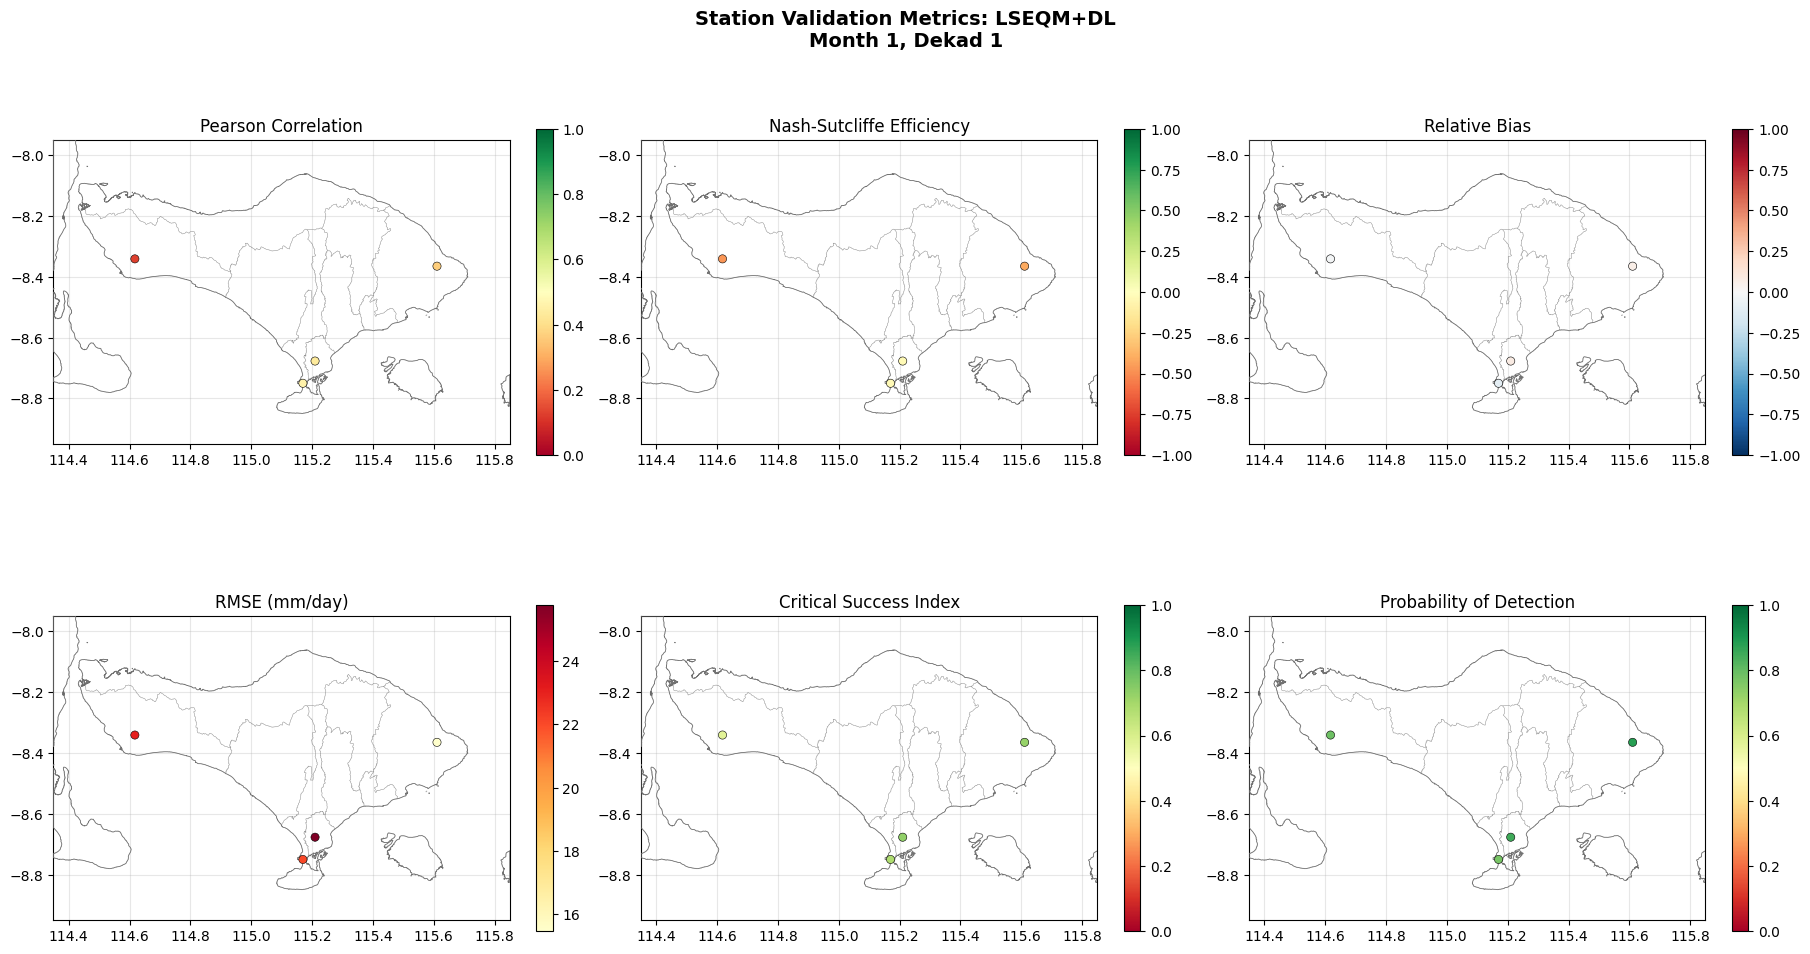

In [13]:
"""Step 21: Station metric scatter maps."""
from src.visualisation import plot_station_metric_maps

# Use best method available
sv_best = "LSEQMDL" if "LSEQMDL" in sv_metrics else list(sv_metrics.keys())[-1]

if sv_metrics:
    fig = plot_station_metric_maps(
        sv_metrics[sv_best], station_df, month, dekad,
        method_name=sv_best,
        output_dir=station_viz_dir,
    )
else:
    print("No station validation data available.")

### Step 22: Multi-Threshold Performance Curves

WMO/TD-No. 1485 style performance curves showing how categorical verification
scores (POD, FAR, CSI, FBI, ETS, HSS) change across 7 precipitation intensity
thresholds (1--150 mm/day). Each line represents a correction method.

2026-05-22 04:40:04,516 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/station_validation/station_validation_threshold_curves/bali_cli_qa_viz_station_validation_threshold_curves_month01_dekad01.png


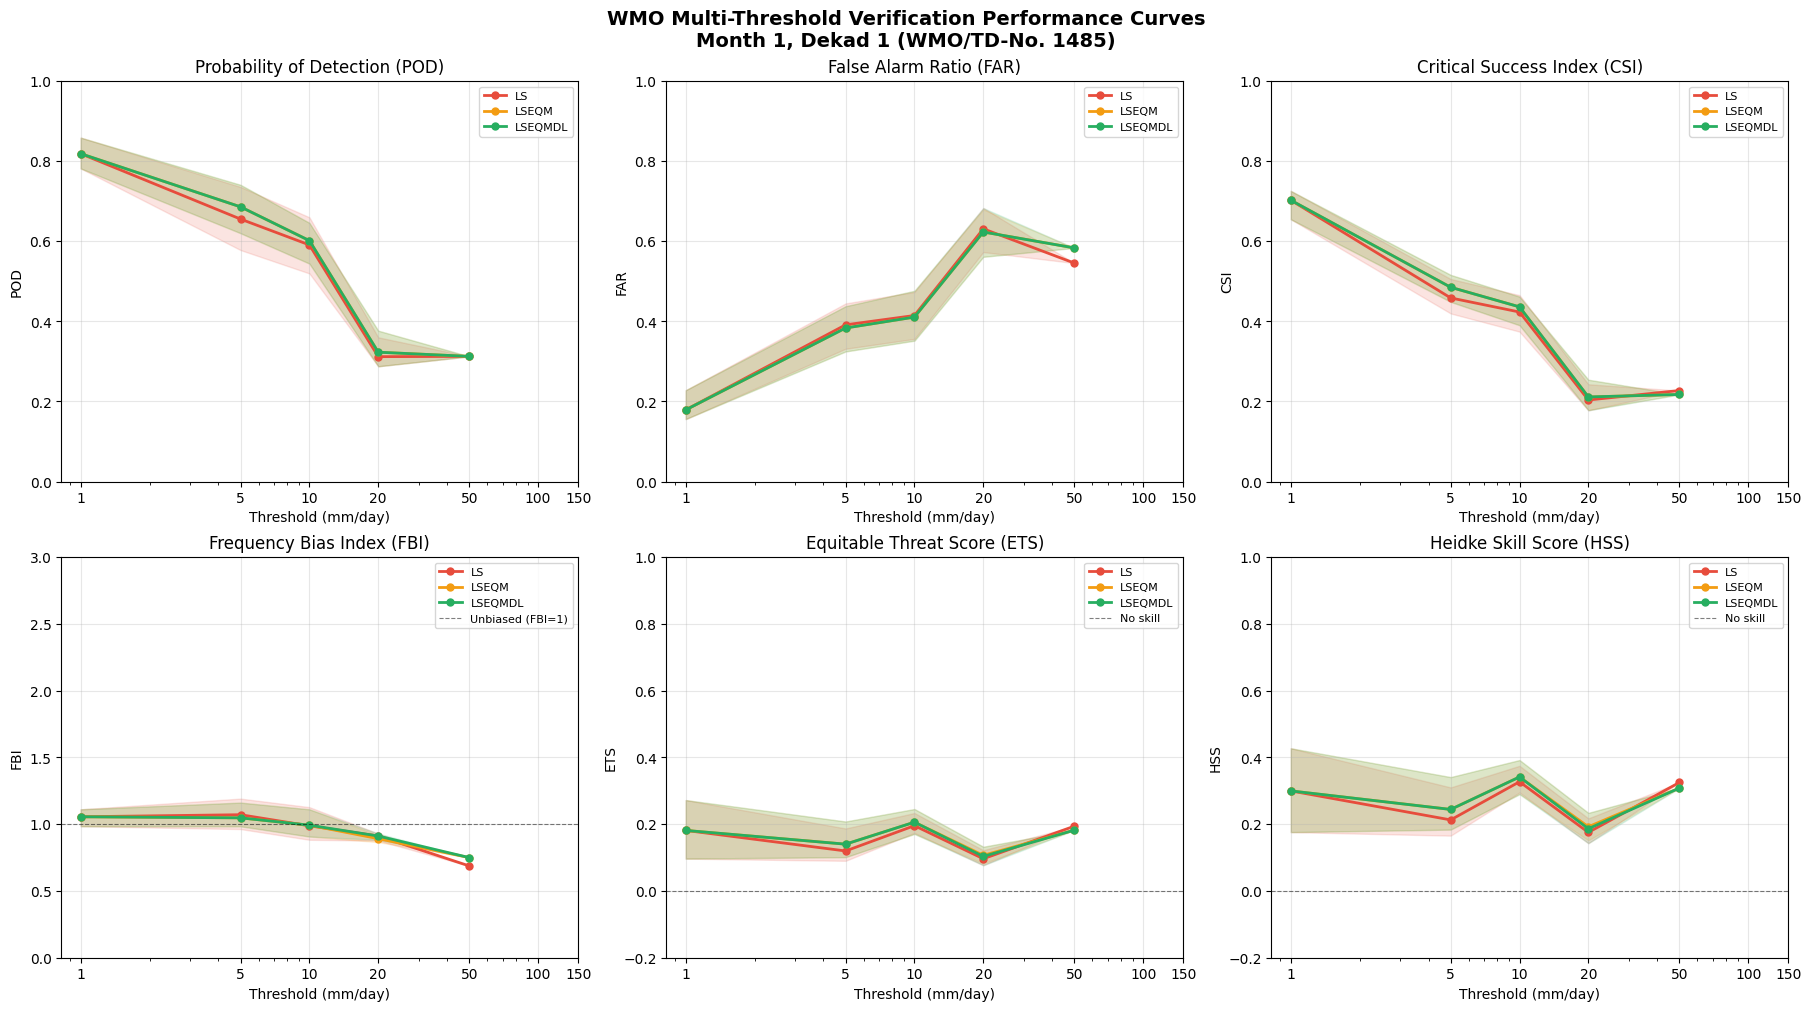

2026-05-22 04:40:06,863 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/station_validation/station_validation_exceedance_frequency/bali_cli_qa_viz_station_validation_exceedance_frequency_month01_dekad01.png


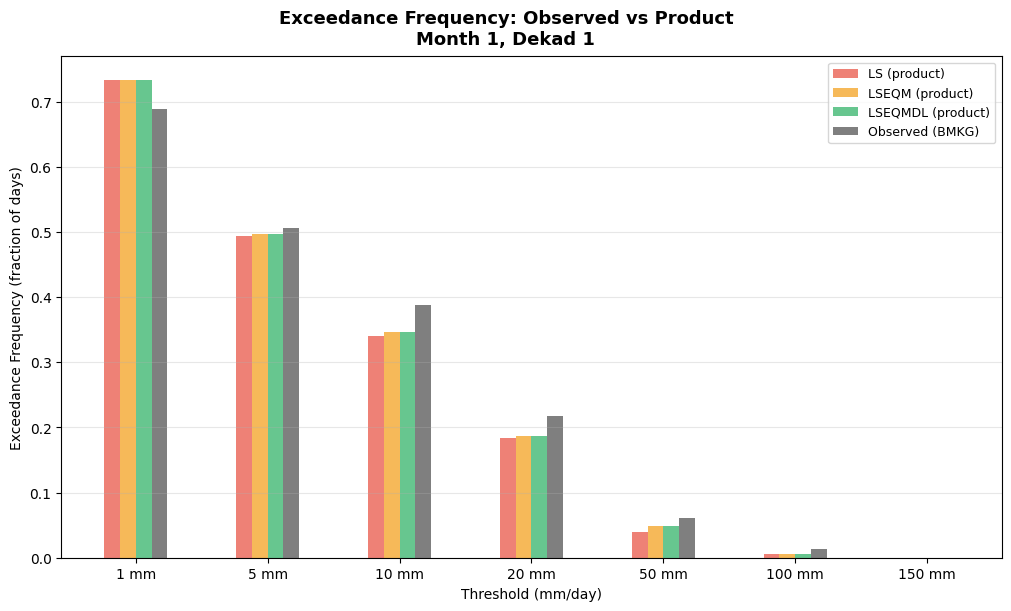

In [14]:
"""Step 22: WMO multi-threshold performance curves."""
from src.visualisation import plot_multi_threshold_curves

if sv_mt_summaries:
    fig = plot_multi_threshold_curves(
        sv_mt_summaries, month, dekad,
        output_dir=station_viz_dir,
    )
else:
    print("No multi-threshold summaries available.")

### Step 23: Regional Box Plots

Box plots of key validation metrics grouped by main island (Region).
Reveals regional differences in correction quality — e.g., densely
gauged Java vs. sparsely gauged Papua.

2026-05-22 04:40:13,487 - INFO - Saved: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/station_validation/station_validation_regional_region/bali_cli_qa_viz_station_validation_regional_region_lseqmdl_month01_dekad01.png


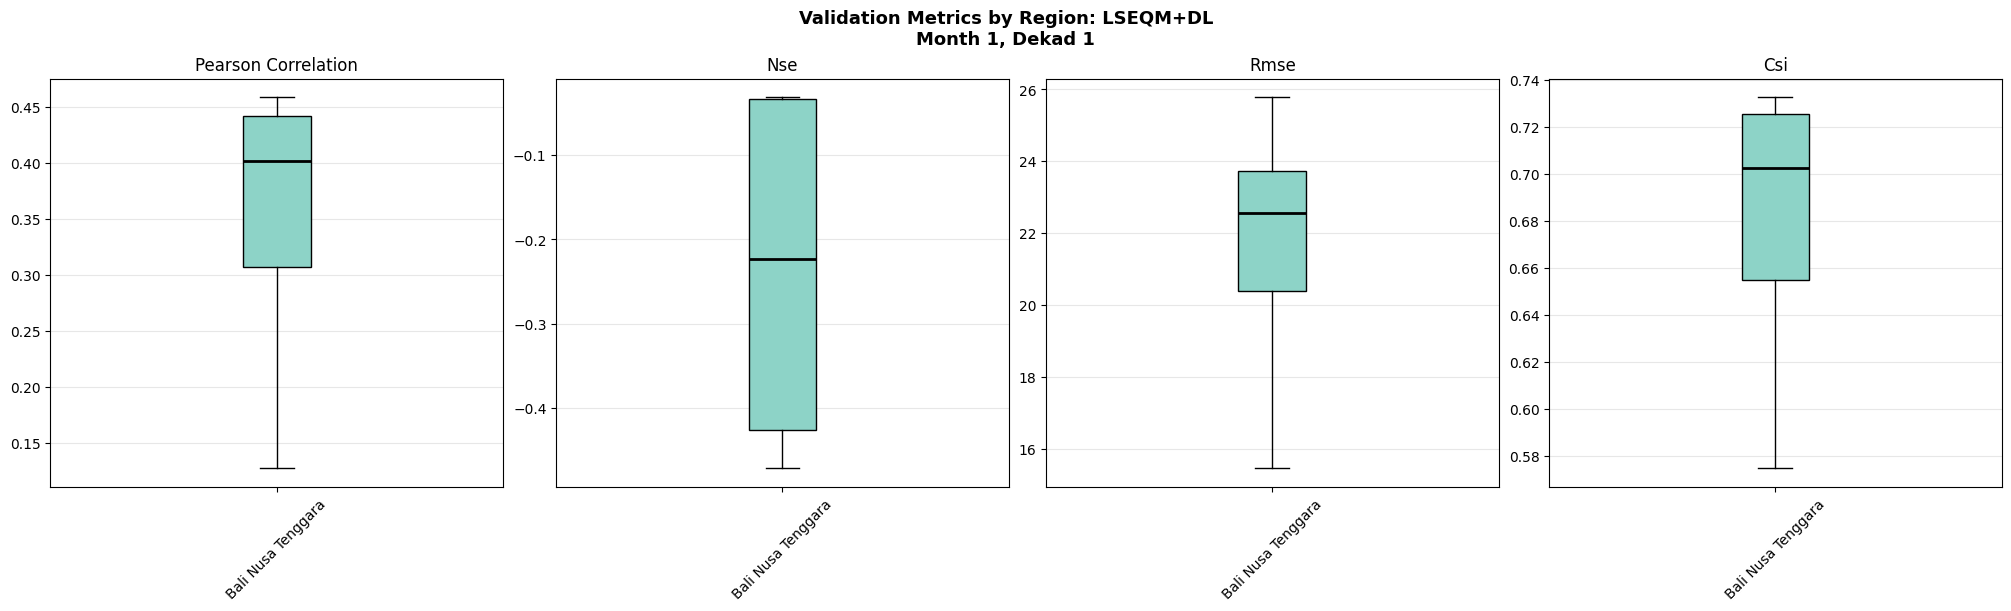

In [15]:
"""Step 23: Regional box plots of station validation metrics."""
from src.visualisation import plot_regional_boxplots
from src.station_validation import merge_station_metadata

if sv_metrics:
    sv_best = "LSEQMDL" if "LSEQMDL" in sv_metrics else list(sv_metrics.keys())[-1]
    regional_df = merge_station_metadata(sv_metrics[sv_best], station_df)
    if "Region" in regional_df.columns:
        fig = plot_regional_boxplots(
            regional_df, month, dekad,
            method_name=sv_best, group_col="Region",
            output_dir=station_viz_dir,
        )
    else:
        print("Region column not found in station metadata.")
else:
    print("No station validation data available.")

---

## Summary

This notebook generated diagnostic visualizations from three complementary
evaluation domains:

1. **QA Framework** (Steps 4--11e): 8 gridded plot types + 4 station-level
   regional/province/station breakdowns from composite quality indices
2. **Taylor Diagrams** (Steps 12--19): Product comparison against BMKG stations
3. **Station Validation** (Steps 20--23): Spatial maps, threshold curves,
   and regional box plots from independent validation

All figures are saved into organized sub-folders under `figures/`.
The unified batch below generates all figures for all 36 periods.

---

### Step 24: Unified Batch -- All Visualization

Generate all figures across all 36 dekadal periods in a single run.
This calls four batch orchestrators:

1. `run_qa_batch_viz()` — 8 QA plot types × 36 periods × 2 quality modes
2. `run_qa_regional_batch_viz()` — QA regional/province/station plots × 36 periods × 2 modes
3. `generate_all_taylor_diagrams()` — 4 Taylor diagram variants + CSV
4. `run_station_validation_batch_viz()` — 3 station validation plot types × 36 periods

> **Prerequisites**: Only **Step 1** (setup) is required.
> Steps 2--23 can be skipped for batch-only runs.

In [ ]:
"""Step 24: Unified batch -- all visualization for all 36 periods."""
from src.visualisation import (
    run_qa_batch_viz,
    run_qa_regional_batch_viz,
    run_station_validation_batch_viz,
)
from src.taylor_diagram import generate_all_taylor_diagrams

# # --- 1. QA Framework plots (8 types x 36 periods x 2 modes) ---
# print("=" * 60)
# print("BATCH 1/4: QA Framework Visualization")
# print("=" * 60)
# qa_summaries = {}
# for _qp in ["qualitysd", "qualityts"]:
#     print(f"\n--- Quality mode: {_qp} ---")
#     qa_summaries[_qp] = run_qa_batch_viz(
#         quality_prefix=_qp,
#         output_dir=figures_dir,
#         config=config,
#         progress=True,
#     )

# # --- 2. QA Regional / Province / Station plots (x 2 modes) ---
# print("\n" + "=" * 60)
# print("BATCH 2/4: QA Regional Breakdown")
# print("=" * 60)
# qa_regional_summaries = {}
# for _qp in ["qualitysd", "qualityts"]:
#     print(f"\n--- Quality mode: {_qp} ---")
#     qa_regional_summaries[_qp] = run_qa_regional_batch_viz(
#         quality_prefix=_qp,
#         output_dir=figures_dir,
#         config=config,
#         progress=True,
#     )

# --- 3. Taylor Diagrams ---
print("\n" + "=" * 60)
print("BATCH 3/4: Taylor Diagram Generation")
print("=" * 60)
try:
    td_acc, td_locs = generate_all_taylor_diagrams(
        config,
        output_dir=taylor_output_dir,
    )
    print("Taylor diagrams generated successfully.")
except Exception as e:
    print(f"Taylor diagram generation failed: {e}")

# # --- 4. Station Validation plots (3 types x 36 periods) ---
# print("\n" + "=" * 60)
# print("BATCH 4/4: Station Validation Visualization")
# print("=" * 60)
# sv_summary = run_station_validation_batch_viz(
#     output_dir=station_viz_dir,
#     config=config,
#     progress=True,
# )

print("\n" + "=" * 60)
print("ALL BATCHES COMPLETE")
print("=" * 60)


BATCH 3/4: Taylor Diagram Generation
  Taylor Diagram Generation

Step 1/8: Computing statistics across all dekads ...
  Loaded 4 station locations
  Matched 4/4 stations to obs data
  Station obs: 7670 rows, 2001-01-01 00:00:00 to 2021-12-31 00:00:00, dtype=datetime64[ns]
  Processing dekad  1/36 (month 01, days  1-10) ...    cpc: 250 dates, type=datetime64
    imergl: 250 dates, type=datetime64
    imergf: 250 dates, type=datetime64
    ls: 250 dates, type=datetime64
    lseqm: 250 dates, type=datetime64
    lseqmdl: 250 dates, type=datetime64
  Processing dekad 36/36 (month 12, days 21-31) ...
  Done computing Taylor statistics (184,080 total paired observations).

Step 2/8: Saving pooled statistics CSV ...
  Saved Taylor statistics CSV: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/figures/taylor/taylor_statistics_per_station.csv

Step 3/8: Saving per-dekad statistics CSV ...
  Saved per-dekad Taylor statistics CSV: /content/drive/MyDrive/hybrid-bias-corre

### Step 25: Batch Summary

In [ ]:
"""Step 25: Print aggregated statistics from all batch runs."""
from src.visualisation import print_batch_summary, print_station_validation_viz_summary

print("=== QA Framework Batch ===")
for _qp, _summary in qa_summaries.items():
    print(f"\n--- {_qp} ---")
    print_batch_summary(_summary)

print("\n=== Station Validation Batch ===")
print_station_validation_viz_summary(sv_summary)

---

## End of Code